In [2]:
import matplotlib.pyplot as plt
import distinctipy
import numpy as np 
import pandas as pd 
import os 
import pickle
import matplotlib
import sys
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[2]
sys.path.insert(0, str(REPO_ROOT / "code"))
from plot_of_experiment_data import *
from make_network import sez
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

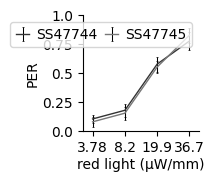

In [11]:
# intensity dependent PER

fpath = 'data/intensity_dependent_PER.xlsx'
sheets = pd.ExcelFile(fpath)
sheets = sheets.sheet_names
df_all = {}
for s in sheets:
    df_all[s] = pd.read_excel(fpath,sheet_name=s)

    
fig,ax = plt.subplots(1,1,figsize=(1.5,1.5))
cmap = ['#333333','#777777']
fontsize=10
lw = 1
elw = .75
ms = 0
cs= 1
lp = 2
ct = .5
ecolor = 'black'



p1 = ax.errorbar(list(range(4)),np.nanmean(df_all['SS47744'].values,axis=0),yerr=std_err(df_all['SS47744'].values),linewidth=lw,elinewidth=elw,markersize=ms,fmt='-o',capsize=cs,color=cmap[0],ecolor=ecolor,capthick=ct)

p2 = ax.errorbar(list(range(4)),np.nanmean(df_all['SS47745'].values,axis=0),yerr=std_err(df_all['SS47745'].values),linewidth=lw,elinewidth=elw,markersize=ms, fmt='-o',capsize=cs,color=cmap[1],ecolor=ecolor,capthick=ct)

ax.set_xticks(list(range(4)),list(df_all['SS47744'].columns.values),fontsize=fontsize)
ax.set_yticks(list(np.arange(0,1.25,.25)),np.round(list(np.arange(0,1.2,.25)),2),fontsize=fontsize)
ax.set_ylabel('PER',fontsize=fontsize,labelpad=lp)
xlabel = '$\mathrm{red light} \mathrm{(μW/mm}^2\mathrm{)}$'
ax.set_xlabel('red light (μW/mm)',fontsize=fontsize,labelpad=lp)

ax.set_ylim([0,1])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(-0.3, 3.3) 
p = [p1,p2]



ax.legend(['SS47744','SS47745'],fontsize=fontsize,ncol=2,handlelength=1, columnspacing=.5,handletextpad=.5)


# plt.savefig(f'light_intensity_dependent_PER.svg',bbox_inches='tight')

In [48]:
# =========================================
# Total list of experiments: 1st + 2nd
# =========================================

fpath = 'data/Opto. SEZ2021 135 celltypes 250911.xlsx'

data_df_optogenetics = pd.read_excel(
    fpath,
    sheet_name='Opto. SEZ2021 lines'
)


# 1st + 2nd line 모두
line2type = {
    **dict(zip(
        data_df_optogenetics['1st line'],
        data_df_optogenetics['Targeted cell type']
    )),
    **dict(zip(
        data_df_optogenetics['2nd line'],
        data_df_optogenetics['Targeted cell type']
    ))
}

line2type.pop(np.nan, None)

total_list_of_exps = np.sort(list(line2type.keys()))


# =========================================
# 1st line만 따로 저장
# =========================================

line2type_1st = dict(
    zip(
        data_df_optogenetics['1st line'],
        data_df_optogenetics['Targeted cell type']
    )
)

line2type_1st.pop(np.nan, None)

total_list_of_exps_1st = np.sort(
    list(line2type_1st.keys())
)


# =========================================
# Optogenetic activation
# =========================================

fpath = 'data/optogenetics_hit.xlsx'

data_df = pd.read_excel(
    fpath,
    sheet_name='- geosmin'
)

data_df2 = pd.read_excel(
    fpath,
    sheet_name='- geosmin 2nd'
)


# line 이름
splitlines = [
    x.split(' ')[-1]
    for x in data_df.columns
]

splitlines2 = [
    x.split(' ')[-1]
    for x in data_df2.columns
]


# mean
mean_data = data_df.mean(axis=0)
mean_data.index = splitlines

mean_data2 = data_df2.mean(axis=0)
mean_data2.index = splitlines2


# SEM
std_data = std_err(data_df)
std_data.index = splitlines

std_data2 = std_err(data_df2)
std_data2.index = splitlines2


# =========================================
# ALL: 1st + 2nd
# =========================================

mean_data_all = pd.Series(
    0.0,
    index=total_list_of_exps
)

std_data_all = pd.Series(
    0.0,
    index=total_list_of_exps
)

mean_data_all.update(mean_data)
mean_data_all.update(mean_data2)

std_data_all.update(std_data)
std_data_all.update(std_data2)


mean_data_all = mean_data_all.to_frame('mean')
std_data_all = std_data_all.to_frame('sem')

mean_data_all['canonical'] = [
    line2type[x]
    for x in mean_data_all.index
]


# =========================================
# 1st line only
# =========================================

mean_data_1st = mean_data_all.loc[
    mean_data_all.index.intersection(
        total_list_of_exps_1st
    )
].copy()

std_data_1st = std_data_all.loc[
    std_data_all.index.intersection(
        total_list_of_exps_1st
    )
].copy()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

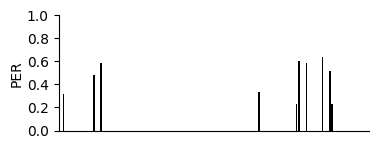

In [49]:
# F
line2type_1st = dict(
    zip(
        data_df_optogenetics['1st line'],
        data_df_optogenetics['Targeted cell type']
    )
)

line2type_1st.pop(np.nan, None)

total_list_of_exps_1st = np.sort(list(line2type_1st.keys()))

mean_data_1st = mean_data_all.loc[
    mean_data_all.index.intersection(total_list_of_exps_1st)
].copy()


fig, ax = plt.subplots(1, 1, figsize=(4, 1.5))

cmap = ['#000000']
fontsize = 10
lp = 2

bar_spacing = 5
bar_width = 3

num_bars = len(mean_data_1st)
x = np.arange(0, num_bars * bar_spacing, bar_spacing)


# Bar plot
ax.bar(
    x,
    mean_data_1st['mean'].values,
    width=bar_width,
    color=cmap[0],
    linewidth=0.5
)


# Y axis
ax.set_yticks(
    np.arange(0, 1.1, 0.2),
    np.round(np.arange(0, 1.1, 0.2), 2),
    fontsize=fontsize
)

ax.set_ylabel(
    'PER',
    fontsize=fontsize,
    labelpad=lp
)

ax.set_ylim([0, 1.0])


# X axis
ax.set_xticks([])

# 기존 xlim 그대로
ax.set_xlim([
    -10,
    np.max(x) + 2
])


# Spine
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig('data.svg')

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

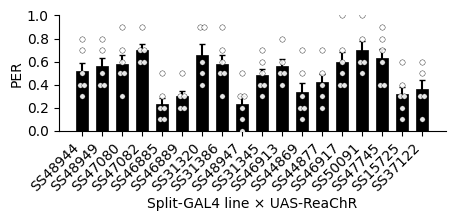

In [50]:
# lines exhibiting hits
hits = []

for canonical, df in mean_data_all.groupby("canonical"):
    hit_df = df.loc[df['mean'] > 0]
    
    if not hit_df.empty:
        hits.append(hit_df)

hits = pd.concat(hits)

hits_sem = std_data_all.loc[hits.index]
hits_sem['canonical'] = hits.canonical


# 각 막대에 해당하는 Split-GAL4 line
conditions = hits.index.tolist()
groups = ["ReaChR"]


# 평균값
def get_mean(cond, group):
    value = hits.loc[cond, 'mean']

    # 동일한 index가 여러 개 존재할 때 대비
    if isinstance(value, pd.Series):
        return value.iloc[0]

    return value


def get_err(cond, group):
    value = hits_sem.loc[cond, 'sem']

    # 동일한 index가 여러 개 존재할 때 대비
    if isinstance(value, pd.Series):
        return value.iloc[0]

    return value

# raw data
# data_all에서 각 column이 Split-GAL4 line인 경우
def get_values(cond, group):
    return data_all[cond].dropna().to_numpy()


fig, ax = plt.subplots(
    1,
    1,
    figsize=(5, 1.5)
)

fontsize = 10
labelpad = 2

x_loc = draw_bar_with_points(
    ax=ax,
    conditions=conditions,
    groups=groups,
    get_values=get_values,
    get_mean=get_mean,
    get_err=get_err,
    bar_width=0.15,
    bar_spacing=0.25,
    colors=["#000000"],
    edgecolor="black",
    linewidth=0.5,
    capsize=2,
    point_facecolor="white",
    point_edgecolor="black",
    point_lw=0.3,
    point_size=15,
    point_alpha=0.9,
)

ax.set_xticks(
    x_loc,
    conditions,
    fontsize=fontsize,
    horizontalalignment="right",
    rotation=45,
)

yticks = np.arange(0, 1.01, 0.2)

ax.set_yticks(
    yticks,
    np.round(yticks, 2),
    fontsize=fontsize,
)

ax.set_ylabel(
    "PER",
    fontsize=fontsize,
    labelpad=labelpad,
)

ax.set_xlabel(
    "Split-GAL4 line × UAS-ReaChR",
    fontsize=fontsize,
    labelpad=labelpad,
)

ax.set_ylim(0, 1.0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.savefig(
    "optogenetics_result_in_bar_points_only_hits_250924.svg",
    bbox_inches="tight",
)

plt.show()